## This notebook calculates the theory behind SPLICE, an interferometric scheme to distribute two mode squeezed light.

In [57]:
import sympy as sp
from sympy import pi, I
from sympy.simplify.fu import TR8,fu
import numpy as np
import matplotlib.pyplot as plt

from sympy.physics.quantum.boson import BosonOp, BosonFockKet
from sympy.physics.quantum import Dagger
from collections import defaultdict




def collect_linear_modes(expr):
    """Collect a linear expression by its embedded tensor-product operators.

    No operator reordering is performed here.
    """
    expr = sp.expand_mul(expr)
    coeffs = defaultdict(lambda: sp.S.Zero)
    remainder = []

    for term in sp.Add.make_args(expr):
        comm, nc = term.args_cnc()
        if len(nc) == 1 and nc[0] in mode_basis_set:
            coeffs[nc[0]] += sp.Mul(*comm)
        else:
            remainder.append(term)

    pieces = [coeff * op for op, coeff in coeffs.items() if coeff != 0]
    pieces.extend(remainder)
    return sp.Add(*pieces)

In [ ]:
#Let us start by defining some terms
alpha = sp.symbols('alpha', real=True, positive=True) #LO amplitude
a_s = BosonOp('a_s') #signal mode
a_i = BosonOp('a_i') #idler mode
v_i = BosonOp('v_i') #vacuum mode for idler
v_s = BosonOp('v_s') #vacuum mode for signal

ops = [a_s, a_i, v_s, v_i]
mode_basis = [
    a_s, Dagger(a_s),
    a_i, Dagger(a_i),
    v_s, Dagger(v_s),
    v_i, Dagger(v_i),
]
mode_basis_set = set(mode_basis)

Omega = sp.symbols('\Omega', real=True, positive=True) #frequency shift in the idler/signal path
t = sp.symbols('t', real=True, positive=True) #time
phi_0 = sp.symbols('\phi_0', real=True) #Central phase of the interferometer
k = sp.symbols('k', real=True, positive=True) #Proportionality constant in interferometer. k = 2*pi*n*deltaL/c. 
theta_s = sp.symbols('\theta_s', real=True) #Phase of the signal (After the interferometer)
theta_i = sp.symbols('\theta_i', real=True) #Phase of the idler (After the interferometer)

#Start with the input to the interferometer
E_1in = alpha*(1+I)+v_s*sp.exp(I*Omega*t) + v_i*sp.exp(-I*Omega*t)
E_2in = a_s*sp.exp(I*Omega*t) + a_i*sp.exp(-I*Omega*t)
#Begin by writing out the long and short path of the interferometer.
E_S = 1/sp.sqrt(2)*(E_1in-I*E_2in)
E_L = 1/sp.sqrt(2)*(E_2in-I*E_1in)*sp.exp(I*(phi_0))
#For E_L, include a phase shift of k*Omega for a_s and v_s, and -k*Omega for a_i and v_i.
E_L = E_L.subs({a_s: a_s*sp.exp(I*k*Omega), v_s: v_s*sp.exp(I*k*Omega), a_i: a_i*sp.exp(-I*k*Omega), v_i: v_i*sp.exp(-I*k*Omega)})

#NOTE: By having alpha as alpha*(1+I), the actual power of the LO is 2*alpha^2. 

#Now after the beamsplitter.
E_1 = 1/sp.sqrt(2)*(E_S - I*E_L)
E_2 = 1/sp.sqrt(2)*(E_L - I*E_S)

E_1 = E_1.expand()
E_2 = E_2.expand()

#Collect in terms of a_s, a_i, v_s, v_i and alpha
E_1 = collect_linear_modes(E_1)
E_2 = collect_linear_modes(E_2)
E_1 = E_1.collect(alpha/2)
E_2 = E_2.collect(alpha/2)

print(r"E_1 = ")
display(E_1)
print(r"E_2 = ")
display(E_2)

E_1 = 


alpha*(-exp(I*\phi_0) - I*exp(I*\phi_0) + 1 + I)/2 + (-exp(I*\phi_0)*exp(-I*\Omega*k)*exp(-I*\Omega*t)/2 + exp(-I*\Omega*t)/2)*v_i + (-exp(I*\phi_0)*exp(I*\Omega*k)*exp(I*\Omega*t)/2 + exp(I*\Omega*t)/2)*v_s + (-I*exp(I*\phi_0)*exp(-I*\Omega*k)*exp(-I*\Omega*t)/2 - I*exp(-I*\Omega*t)/2)*a_i + (-I*exp(I*\phi_0)*exp(I*\Omega*k)*exp(I*\Omega*t)/2 - I*exp(I*\Omega*t)/2)*a_s

E_2 = 


alpha*(exp(I*\phi_0) - I*exp(I*\phi_0) + 1 - I)/2 + (exp(I*\phi_0)*exp(-I*\Omega*k)*exp(-I*\Omega*t)/2 - exp(-I*\Omega*t)/2)*a_i + (exp(I*\phi_0)*exp(I*\Omega*k)*exp(I*\Omega*t)/2 - exp(I*\Omega*t)/2)*a_s + (-I*exp(I*\phi_0)*exp(-I*\Omega*k)*exp(-I*\Omega*t)/2 - I*exp(-I*\Omega*t)/2)*v_i + (-I*exp(I*\phi_0)*exp(I*\Omega*k)*exp(I*\Omega*t)/2 - I*exp(I*\Omega*t)/2)*v_s

In [59]:
#I will now do some simple tests to confirm that the expressions are correct
E_1_test = E_1.subs(phi_0,pi/2) #test phi_o to pi/2
E_2_test = E_2.subs(phi_0,pi/2) #test phi_o to pi/2
#Now try setting k*Omega to pi/2
E_1_test = E_1_test.subs(k*Omega,pi/2)
E_2_test = E_2_test.subs(k*Omega,pi/2)
display(E_1_test)
display(E_2_test) 
#The above tests give good results

alpha + exp(I*\Omega*t)*v_s - I*exp(-I*\Omega*t)*a_i

alpha - exp(I*\Omega*t)*a_s - I*exp(-I*\Omega*t)*v_i

In [60]:
#Now it is time for photodetection of E_1 and E_2
i_1 = Dagger(E_1)*E_1
i_2 = Dagger(E_2)*E_2
i_1 = collect_linear_modes(i_1)
i_2 = collect_linear_modes(i_2)
i_1 = i_1.collect(alpha)
i_2 = i_2.collect(alpha)
#Now remove all terms not proportional to alpha, since we are only interested in the terms that will contribute to the photocurrent.
i_1 = sp.Add(*(t for t in sp.expand(i_1).as_ordered_terms()
                    if t.has(alpha)))
i_2 = sp.Add(*(t for t in sp.expand(i_2).as_ordered_terms()
                    if t.has(alpha)))
# # rewrite exp(I*...) to cos and sin 
i_1 = i_1.rewrite(sp.exp, sp.cos, sp.sin)
i_2 = i_2.rewrite(sp.exp, sp.cos, sp.sin)
i_1 = i_1.expand()
i_2 = i_2.expand()
i_1 = collect_linear_modes(i_1)
i_2 = collect_linear_modes(i_2)




In [61]:
#Now we wish to demodulate and LPF the photocurrents. 
#This is done by multiplying the photocurrent with cos(Omega*t) and sin(Omega*t), and then removing any terms that are not proportional to cos(Omega*t) or sin(Omega*t). 
I_1 = i_1*sp.cos(Omega*t) #This is the I component of the demodulated photocurrent.
Q_1 = i_1*sp.sin(Omega*t) #This is the Q component of the demodulated photocurrent.
I_2 = i_2*sp.cos(Omega*t+pi/2) #I demodulate with pi/2 phase shift since I have a phase shift of pi/2 coming from the interferometer.
Q_2 = i_2*sp.sin(Omega*t+pi/2) 
#The electronic demulation phase can be arbitrarily chosen above. However, the code below might need to be adjusted if the demodulation phase is changed.

#Now collect terms proportional to cos(Omega*t) and sin(Omega*t) and remove them This is done the exact same for all, so we create a function
def demodulate_and_lpf(expr):
    expr = sp.expand(expr)
    expr = sp.collect(expr, [sp.cos(Omega*t), sp.sin(Omega*t)])
    #If the expression has any terms that are sin^2 or cos^2, replace these by 1/2. Otherwise renmove them
    expr = expr.replace(sp.cos(Omega*t)**2, 1/2).replace(sp.sin(Omega*t)**2, 1/2)
    expr = expr.replace(sp.cos(Omega*t), 0).replace(sp.sin(Omega*t), 0.)
    return expr

I_1 = demodulate_and_lpf(I_1)
Q_1 = demodulate_and_lpf(Q_1)
I_2 = demodulate_and_lpf(I_2)
Q_2 = demodulate_and_lpf(Q_2)

In [62]:
#Now let us define quadratures 
#Now rewrite in terms of the quadratures X_s, Y_s, X_i, Y_i, X_vs, Y_vs, X_vi, Y_vi
X_s = sp.symbols('X_s', complex=True)
Y_s = sp.symbols('Y_s', complex=True)
X_i = sp.symbols('X_i', complex=True)
Y_i = sp.symbols('Y_i', complex=True)
X_vs = sp.symbols('X_{vs}', complex=True)
Y_vs = sp.symbols('Y_{vs}', complex=True)
X_vi = sp.symbols('X_{vi}', complex=True)
Y_vi = sp.symbols('Y_{vi}', complex=True)

def quadrature_subs(expr):
    expr = expr.subs({a_s: (X_s + I*Y_s)/sp.sqrt(2), Dagger(a_s): (X_s - I*Y_s)/sp.sqrt(2),
                      a_i: (X_i + I*Y_i)/sp.sqrt(2), Dagger(a_i): (X_i - I*Y_i)/sp.sqrt(2),
                      v_s: (X_vs + I*Y_vs)/sp.sqrt(2), Dagger(v_s): (X_vs - I*Y_vs)/sp.sqrt(2),
                      v_i: (X_vi + I*Y_vi)/sp.sqrt(2), Dagger(v_i): (X_vi - I*Y_vi)/sp.sqrt(2)})
    return expr
I_1 = quadrature_subs(I_1).expand()
Q_1 = quadrature_subs(Q_1).expand()
I_2 = quadrature_subs(I_2).expand()
Q_2 = quadrature_subs(Q_2).expand()

In [63]:
#I will now do some simple tests to confirm that the expressions are correct. Create a function for tihs
def test_expr(expr,name=""):
    expr_test = expr.subs(phi_0,pi/2) #test phi_o to pi/2
    expr_test = expr_test.subs(k*Omega,pi/2)
    #Collect alpha/2
    expr_test = expr_test.expand()
    expr_test = expr_test.collect(alpha)
    expr_test = expr_test.collect(0.5)
    expr_test = expr_test.collect(sp.sqrt(2))
    print(f"Testing expression {name}")
    display(expr_test)

test_expr(I_1, "I_1")
test_expr(Q_1, "Q_1")
test_expr(I_2, "I_2")
test_expr(Q_2, "Q_2")
#Above looks pretty good? 

Testing expression I_1


0.5*sqrt(2)*alpha*(X_{vs} + Y_i)

Testing expression Q_1


0.5*sqrt(2)*alpha*(-X_i - Y_{vs})

Testing expression I_2


0.5*sqrt(2)*alpha*(X_{vi} - Y_s)

Testing expression Q_2


0.5*sqrt(2)*alpha*(-X_s + Y_{vi})

In [64]:
#Now it is time to construct sum and differences of the demodulated photocurrents.
I_sum = I_1 + I_2
I_diff = I_1 - I_2
Q_sum = Q_1 + Q_2
Q_diff = Q_1 - Q_2

r = sp.symbols('r', real=True, positive=True) #squeezing
eta = sp.symbols('\eta', real=True, positive=True) #efficiency

#Now we should square the sum and difference signals, and then take the expectation value of these.
#Since we are doing the same for each expression, we can create a function for this.
def square_and_expectation(expr,lossless=True):
    expr = expr**2
    expr = expr.expand()
    #Collect in terms of a_s, a_i, v_s, v_i and alpha
    expr = collect_linear_modes(expr)
    expr = expr.collect(alpha)
    #Collect in terms of the quadratures
    expr = sp.collect(expr, [X_s*Y_s, X_i*Y_i, X_vs*Y_vs, X_vi*Y_vi])
    #Now we use the covariance matrix to determine the expectation value of the expression.
    #Set same quadratures to cosh(2r)/2, and X_s*X_i to sinh(2r)/2 and Y_s*Y_i to -sinh(2r)/2. All other quadrature products are set to 0.
    expr = expr.subs({X_s*X_s: eta*sp.cosh(2*r) + (1-eta), Y_s*Y_s: eta*sp.cosh(2*r) + (1-eta),
                        X_i*X_i: eta*sp.cosh(2*r) + (1-eta), Y_i*Y_i: eta*sp.cosh(2*r) + (1-eta),
                        X_vs*X_vs: 1, Y_vs*Y_vs: 1,
                        X_vi*X_vi: 1, Y_vi*Y_vi: 1,
                        X_s*X_i: eta*sp.sinh(2*r), Y_s*Y_i: -eta*sp.sinh(2*r),})
    if lossless:
        expr = expr.subs(eta, 1)
    #Set any remaining quadratures  to 0.
    expr = expr.subs({X_s: 0, Y_s: 0, X_i: 0, Y_i: 0, X_vs: 0, Y_vs: 0, X_vi: 0, Y_vi: 0})*1/2 #I need to multiply by 1/2 since hbar = 1 in this case
    expr = expr.expand()
    return expr

I_sum_var = square_and_expectation(I_sum,lossless=False)
I_diff_var = square_and_expectation(I_diff,lossless=False)
Q_sum_var = square_and_expectation(Q_sum,lossless=False)
Q_diff_var = square_and_expectation(Q_diff,lossless=False)
display(I_sum_var)

0.125*\eta*alpha**2*sin(\phi_0)**2*sin(\Omega*k)**2*cosh(2*r) - 0.125*\eta*alpha**2*sin(\phi_0)**2*sin(\Omega*k)**2 + 0.125*\eta*alpha**2*sin(\phi_0)**2*cos(\Omega*k)**2*cosh(2*r) - 0.125*\eta*alpha**2*sin(\phi_0)**2*cos(\Omega*k)**2 + 0.25*\eta*alpha**2*sin(\phi_0)**2*cos(\Omega*k)*cosh(2*r) - 0.25*\eta*alpha**2*sin(\phi_0)**2*cos(\Omega*k) + 0.125*\eta*alpha**2*sin(\phi_0)**2*cosh(2*r) - 0.125*\eta*alpha**2*sin(\phi_0)**2 - 0.25*\eta*alpha**2*sin(\phi_0)*sin(\Omega*k)**2*cos(\phi_0)*sinh(2*r) + 0.5*\eta*alpha**2*sin(\phi_0)*sin(\Omega*k)*sinh(2*r) - 0.25*\eta*alpha**2*sin(\phi_0)*cos(\phi_0)*cos(\Omega*k)**2*sinh(2*r) + 0.25*\eta*alpha**2*sin(\phi_0)*cos(\phi_0)*sinh(2*r) + 0.125*\eta*alpha**2*sin(\Omega*k)**2*cos(\phi_0)**2*cosh(2*r) - 0.125*\eta*alpha**2*sin(\Omega*k)**2*cos(\phi_0)**2 + 0.125*\eta*alpha**2*sin(\Omega*k)**2*cosh(2*r) - 0.125*\eta*alpha**2*sin(\Omega*k)**2 + 0.125*\eta*alpha**2*cos(\phi_0)**2*cos(\Omega*k)**2*cosh(2*r) - 0.125*\eta*alpha**2*cos(\phi_0)**2*cos(\Omega

In [65]:
#We will now again test expression by setting phi_0 = pi/2 and k*Omega = pi/2. Create a function for this.
def test_expectation(expr,name=""):
    expr_test = expr.subs(phi_0,pi/2) #test phi_o to pi/2
    expr_test = expr_test.subs(k*Omega,pi/2)
    expr_test = expr_test.expand()
    #Divide by alpha^2 to get the normalized expectation value
    expr_test = expr_test/alpha**2
    #Rewrite sinh and cosh in terms of exp
    expr_test = expr_test.rewrite(sp.cosh, sp.exp).rewrite(sp.sinh, sp.exp)
    expr_test = expr_test.expand()
    print(f"Testing expectation value {name}")
    display(expr_test)

test_expectation(I_sum_var, "I_sum_var")
test_expectation(I_diff_var, "I_diff_var")
test_expectation(Q_sum_var, "Q_sum_var")
test_expectation(Q_diff_var, "Q_diff_var")

Testing expectation value I_sum_var


0.5*\eta*exp(2*r) - 0.5*\eta + 1.0

Testing expectation value I_diff_var


-0.5*\eta + 0.5*\eta*exp(-2*r) + 1.0

Testing expectation value Q_sum_var


0.5*\eta*exp(2*r) - 0.5*\eta + 1.0

Testing expectation value Q_diff_var


-0.5*\eta + 0.5*\eta*exp(-2*r) + 1.0

In [76]:
#We want to lambidy the var with phi_0, k, omega. 
#Also set alpha = 1 for the lambdify, since we are only interested in the normalized expectation value.
I_sum_var_lambda = sp.lambdify((phi_0, k, Omega, r,eta), (I_sum_var/alpha**2).expand(), 'numpy')
I_diff_var_lambda = sp.lambdify((phi_0, k, Omega, r,eta), (I_diff_var/alpha**2).expand(), 'numpy')
Q_sum_var_lambda = sp.lambdify((phi_0, k, Omega, r,eta), (Q_sum_var/alpha**2).expand(), 'numpy')
Q_diff_var_lambda = sp.lambdify((phi_0, k, Omega, r,eta), (Q_diff_var/alpha**2).expand(), 'numpy')
#It is always normalized by alpha, as long as r = 0.

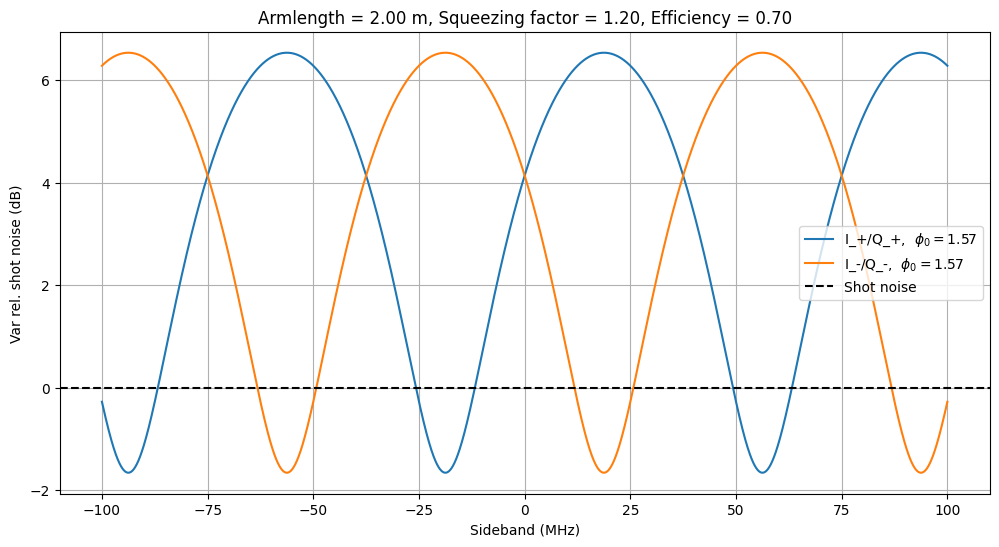

In [92]:
#Now we can plot I_sum_var and I_diff_var as a function of Omega for different values of phi_0. 
def plot_variances(phi_0_values, deltaL,r,eta_value):
    k = 2*np.pi*2*deltaL/3e8 #This is in units of 1/s.
    Omega_values = np.linspace(-100, 100, (int(1e4))) #This is in values of MHz
    plt.figure(figsize=(12, 6))
    #Create custom labels for I_sum, I_diff, Q_sum, Q_diff
    labels = [r'I_+', r'I_-', r'Q_+', r'Q_-']
    for phi_0 in phi_0_values:
        I_sum_var_values = I_sum_var_lambda(phi_0, k, Omega_values*1e6, r,eta_value)
        I_diff_var_values = I_diff_var_lambda(phi_0, k, Omega_values*1e6, r,eta_value)
        Q_sum_var_values = Q_sum_var_lambda(phi_0, k, Omega_values*1e6, r,eta_value)
        Q_diff_var_values = Q_diff_var_lambda(phi_0, k, Omega_values*1e6, r,eta_value)
        #Convert I_sum_var_values and I_diff_var_values to dB
        I_sum_var_values = 10*np.log10(I_sum_var_values)
        I_diff_var_values = 10*np.log10(I_diff_var_values)
        Q_sum_var_values = 10*np.log10(Q_sum_var_values)
        Q_diff_var_values = 10*np.log10(Q_diff_var_values)
        #We now utlize that I_sum and Q_sum are the same, and I_diff and Q_diff are the same. So we only need to plot I_sum and I_diff.
        plt.plot(Omega_values, I_sum_var_values, label=labels[0] + '/' + labels[2] + r',  $\phi_0=$' + f'{phi_0:.2f}')
        plt.plot(Omega_values, I_diff_var_values, label=labels[1] + '/' + labels[3] + r',  $\phi_0=$' + f'{phi_0:.2f}')
        # plt.plot(Omega_values, Q_sum_var_values, label=labels[2]+ r'$\phi_0=$' + f'{phi_0:.2f}', linestyle='--')
        # plt.plot(Omega_values, Q_diff_var_values, label=labels[3]+ r'$\phi_0=$' + f'{phi_0:.2f}', linestyle='--')
        #Add shot noise line
    plt.axhline(y=0, color='k', linestyle='--', label='Shot noise')
    plt.xlabel('Sideband (MHz)')
    plt.ylabel('Var rel. shot noise (dB)')
    plt.title('Armlength = ' + f'{deltaL:.2f}' + ' m, Squeezing factor = ' + f'{r_value:.2f}' + ', Efficiency = ' + f'{eta_value:.2f}')
    plt.legend()
    plt.grid()
    plt.show()
phi_0_values = [0, 1]
phi_0_values = [np.pi/2]
r_value = 1.2
deltaL = 2
eta_value = 0.7
plot_variances(phi_0_values, deltaL, r_value,eta_value)

In [82]:
#Now we want to similarly look at I_1,I_2,Q_1,Q_2. 
#Start by squaring and taking expectation value, followed by lambdifying.
I_1_var = square_and_expectation(I_1)
I_2_var = square_and_expectation(I_2)
Q_1_var = square_and_expectation(Q_1)
Q_2_var = square_and_expectation(Q_2)

In [84]:
display(I_1_var)

0.0625*alpha**2*sin(\phi_0)**2*sin(\Omega*k)**2*cosh(2*r) + 0.0625*alpha**2*sin(\phi_0)**2*sin(\Omega*k)**2 + 0.0625*alpha**2*sin(\phi_0)**2*cos(\Omega*k)**2*cosh(2*r) + 0.0625*alpha**2*sin(\phi_0)**2*cos(\Omega*k)**2 + 0.125*alpha**2*sin(\phi_0)**2*cos(\Omega*k)*cosh(2*r) - 0.125*alpha**2*sin(\phi_0)**2*cos(\Omega*k) + 0.0625*alpha**2*sin(\phi_0)**2*cosh(2*r) + 0.0625*alpha**2*sin(\phi_0)**2 - 0.125*alpha**2*sin(\phi_0)*sin(\Omega*k)**2*cos(\phi_0)*sinh(2*r) + 0.125*alpha**2*sin(\phi_0)*sin(\Omega*k)**2*sinh(2*r) - 0.125*alpha**2*sin(\phi_0)*cos(\phi_0)*cos(\Omega*k)**2*sinh(2*r) + 0.125*alpha**2*sin(\phi_0)*cos(\phi_0)*sinh(2*r) + 0.125*alpha**2*sin(\phi_0)*cos(\Omega*k)**2*sinh(2*r) - 0.125*alpha**2*sin(\phi_0)*sinh(2*r) + 0.0625*alpha**2*sin(\Omega*k)**2*cos(\phi_0)**2*cosh(2*r) + 0.0625*alpha**2*sin(\Omega*k)**2*cos(\phi_0)**2 - 0.125*alpha**2*sin(\Omega*k)**2*cos(\phi_0)*cosh(2*r) - 0.125*alpha**2*sin(\Omega*k)**2*cos(\phi_0) + 0.0625*alpha**2*sin(\Omega*k)**2*cosh(2*r) + 0.0625*

In [86]:
#Now lambdify these expressions as well.
I_1_var_lambda = sp.lambdify((phi_0, k, Omega, r), I_1_var.subs(alpha, 1), 'numpy')
I_2_var_lambda = sp.lambdify((phi_0, k, Omega, r), I_2_var.subs(alpha, 1), 'numpy')
Q_1_var_lambda = sp.lambdify((phi_0, k, Omega, r), Q_1_var.subs(alpha, 1), 'numpy')
Q_2_var_lambda = sp.lambdify((phi_0, k, Omega, r), Q_2_var.subs(alpha, 1), 'numpy')

In [87]:
display(I_1_var.subs({phi_0: pi/2}).simplify())
display(I_2_var.subs({phi_0: pi/2}).simplify())
display(Q_1_var.subs({phi_0: pi/2}).simplify())
display(Q_2_var.subs({phi_0: pi/2}).simplify())

0.25*alpha**2*(cosh(2*r) + 1)

0.25*alpha**2*(cosh(2*r) + 1)

0.25*alpha**2*(cosh(2*r) + 1)

0.25*alpha**2*(cosh(2*r) + 1)

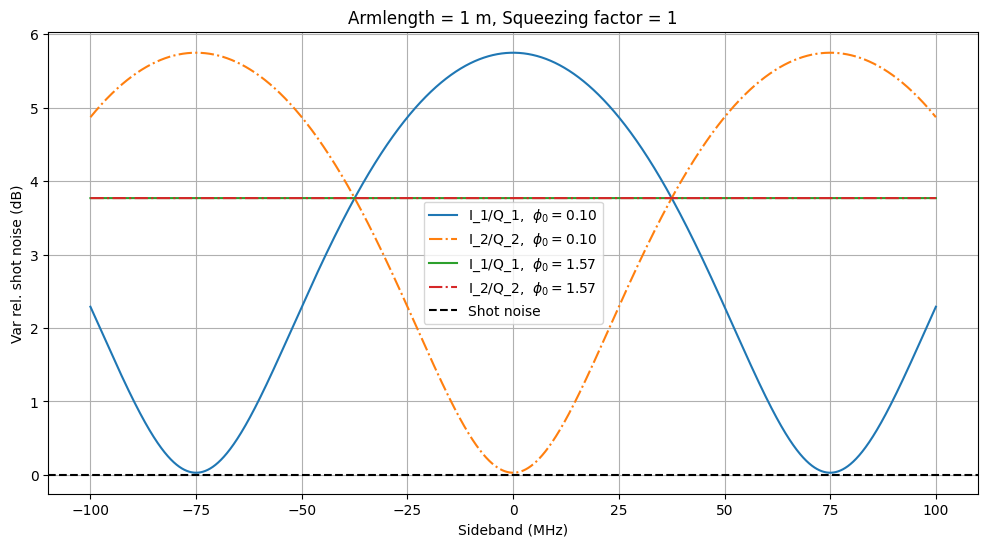

In [89]:
#Now we plot these variances
def plot_single_photocurrents(phi_0_values, deltaL,r,norm_shot):
    k = 2*np.pi*2*deltaL/3e8 #This is in units of 1/s.
    Omega_values = np.linspace(-100, 100, (int(1e4))) #This is in values of MHz
    plt.figure(figsize=(12, 6))
    #Create custom labels for I_1, I_2, Q_1, Q_2
    labels = [r'I_1', r'I_2', r'Q_1', r'Q_2']
    for phi_0 in phi_0_values: 
        if norm_shot:#Here we need to normalize by the value at r = 0, since we are interested in the relative variance.
            I_1_var_values = I_1_var_lambda(phi_0, k, Omega_values*1e6, r)/I_1_var_lambda(phi_0, k, Omega_values*1e6, 0)
            I_2_var_values = I_2_var_lambda(phi_0, k, Omega_values*1e6, r)/I_2_var_lambda(phi_0, k, Omega_values*1e6, 0)
            Q_1_var_values = Q_1_var_lambda(phi_0, k, Omega_values*1e6, r)/Q_1_var_lambda(phi_0, k, Omega_values*1e6, 0)
            Q_2_var_values = Q_2_var_lambda(phi_0, k, Omega_values*1e6, r)/Q_2_var_lambda(phi_0, k, Omega_values*1e6, 0)
        else: #Here we instead always normalize to the input power alpha, which is 1/2
            I_1_var_values = I_1_var_lambda(phi_0, k, Omega_values*1e6, r)*2
            I_2_var_values = I_2_var_lambda(phi_0, k, Omega_values*1e6, r)*2
            Q_1_var_values = Q_1_var_lambda(phi_0, k, Omega_values*1e6, r)*2
            Q_2_var_values = Q_2_var_lambda(phi_0, k, Omega_values*1e6, r)*2
        #Convert to dB
        I_1_var_values = 10*np.log10(I_1_var_values)
        I_2_var_values = 10*np.log10(I_2_var_values)
        Q_1_var_values = 10*np.log10(Q_1_var_values)
        Q_2_var_values = 10*np.log10(Q_2_var_values)
        #Since I_1 and Q_1 are the same, and I_2 and Q_2 are the same, we only need to plot I_1 and I_2.
        plt.plot(Omega_values, I_1_var_values, label=labels[0] + '/' + labels[2] +  r',  $\phi_0=$' + f'{phi_0:.2f}')
        plt.plot(Omega_values, I_2_var_values, label=labels[1] + '/' + labels[3] +  r',  $\phi_0=$' + f'{phi_0:.2f}',linestyle='-.')
    #Add shot noise line
    plt.axhline(y=0, color='k', linestyle='--', label='Shot noise')
    plt.xlabel('Sideband (MHz)')

    plt.ylabel('Var rel. shot noise (dB)')
    plt.title('Armlength = 1 m, Squeezing factor = 1')
    plt.legend()
    plt.grid()
    plt.show()
phi_0_values = [0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
phi_0_values = [0.1,np.pi/2]
r_value = 1
deltaL = 1
plot_single_photocurrents(phi_0_values, deltaL, r_value,norm_shot=True)